In [2]:
import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

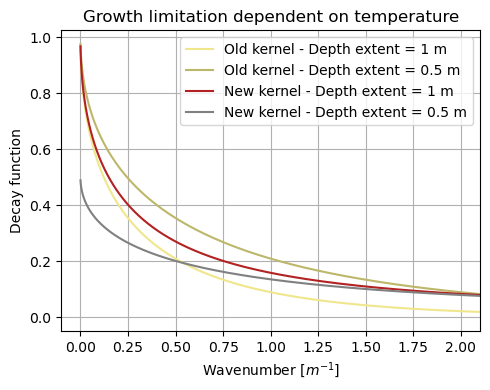

In [3]:
delta_z = 1
delta_z2 = 0.5
T_p = np.arange(0.001,100,0.01)
omega_p = 2. * np.pi / T_p

# Peak wave number
k_p = (omega_p ** 2) / 9.81

# Repeated inner term of Eq. (19) - note depth is negative in this formulation, but model depths are positive by convention
# kp_z_2 = 2. * k_p * particle.depth
kp_z_2 = 2. * k_p * delta_z / 2
kp__  = 2. * k_p * delta_z2 / 2

# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay = np.exp(-kp_z_2) - np.sqrt(np.pi * kp_z_2) * scipy.special.erfc(np.sqrt(kp_z_2))
decay05 = np.exp(-kp__) - np.sqrt(np.pi * kp__) * scipy.special.erfc(np.sqrt(kp__))


#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(delta_z)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(delta_z))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(delta_z)))  
                    - (1 + 2*k_p*(delta_z)) * np.exp(-2*k_p*(delta_z))   )
                    )
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function05 = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(delta_z2)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(delta_z2))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(delta_z2)))  
                    - (1 + 2*k_p*(delta_z2)) * np.exp(-2*k_p*(delta_z2))   )
                    )

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 4))
#Temperature
ax1.plot(k_p, decay,  label='Old kernel - Depth extent = 1 m', color = 'khaki')
ax1.plot(k_p, decay05,  label='Old kernel - Depth extent = 0.5 m', color = 'darkkhaki')
ax1.plot(k_p,  decay_function , label='New kernel - Depth extent = 1 m', color = 'firebrick')
ax1.plot(k_p,  decay_function05 , label='New kernel - Depth extent = 0.5 m', color = 'grey')
ax1.set_xlabel(r'Wavenumber [$m^{-1}$]')
ax1.set_ylabel('Decay function')
ax1.set_title('Growth limitation dependent on temperature')
ax1.grid()
ax1.set_xlim(-0.1, 2.1)
ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

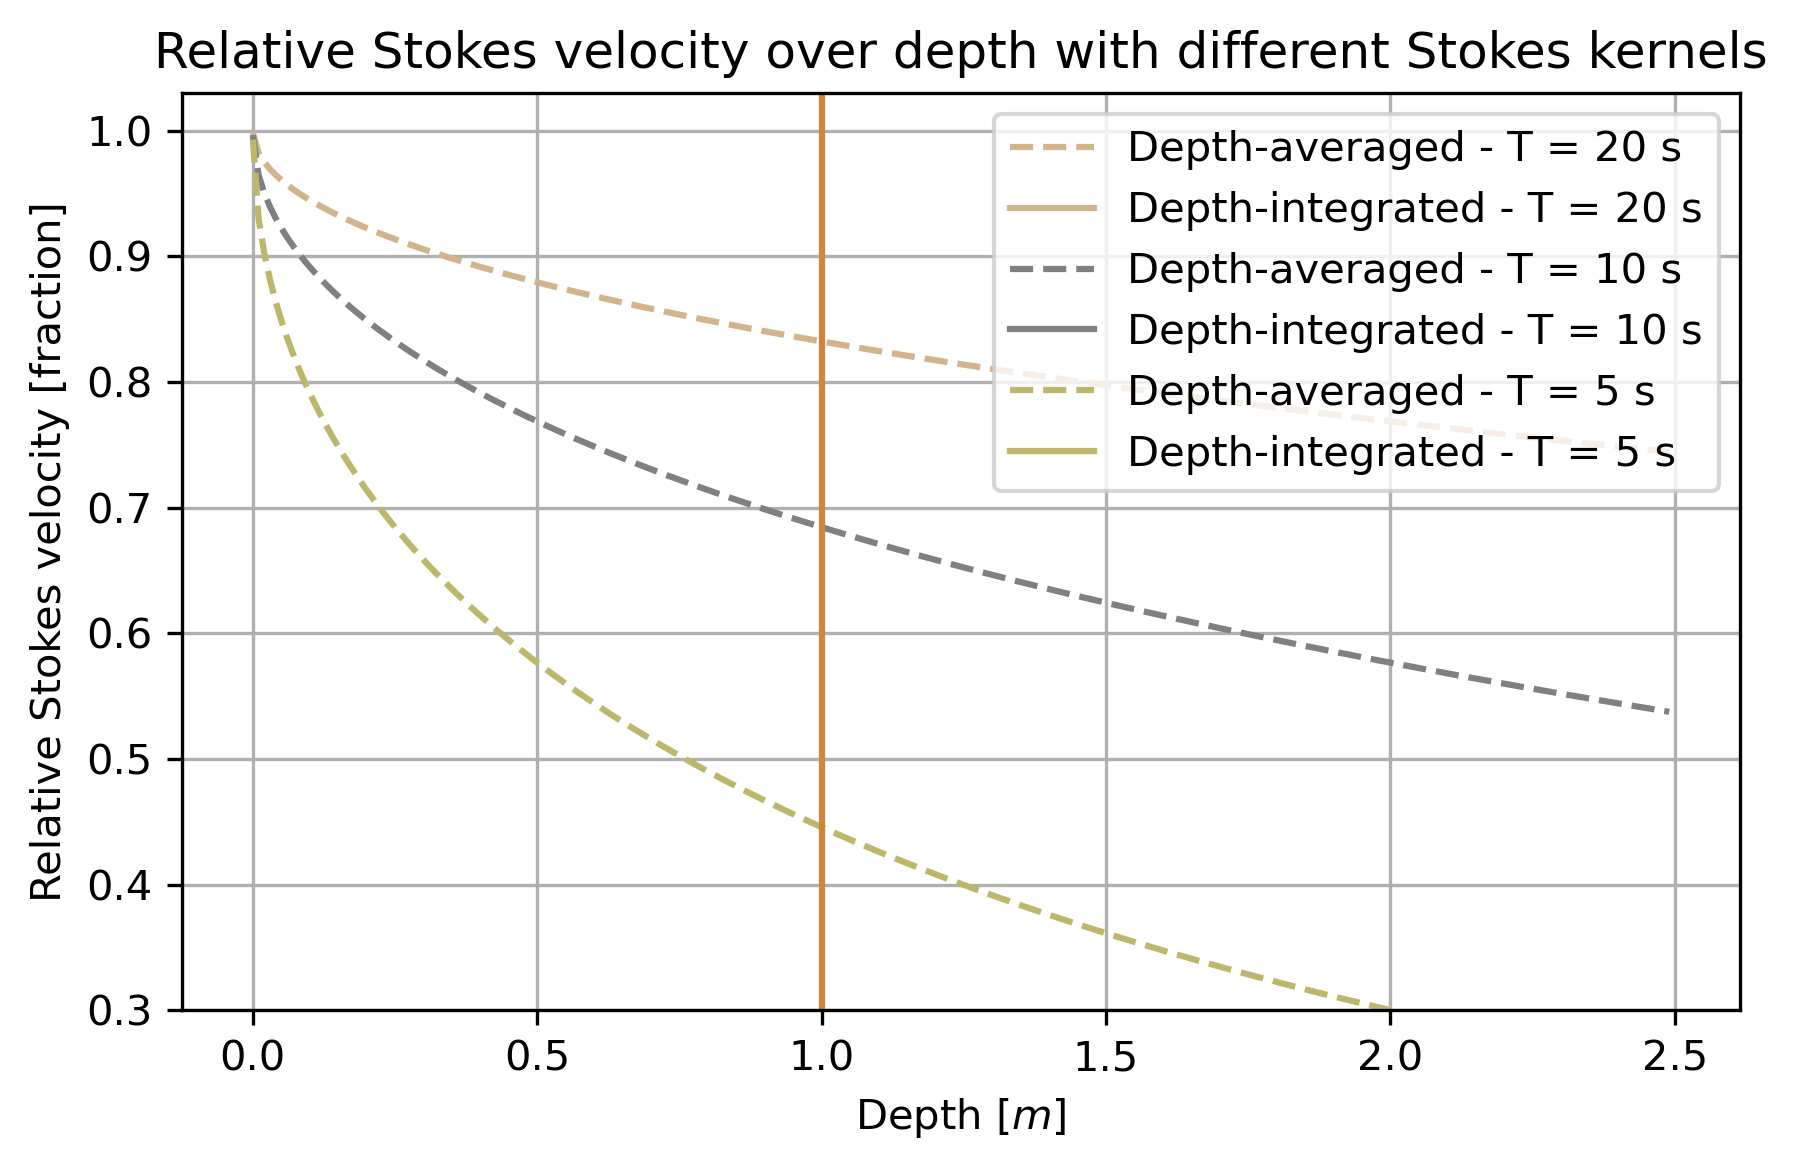

In [ ]:
stokes_surface = 1 # [m/s]
delta_z = np.arange(0.0001,2.5,0.01)

T_p = 10
T_p2 = 5
T_p3 = 20
omega_p = 2. * np.pi / T_p
omega_p2 = 2. * np.pi / T_p2
omega_p3 = 2. * np.pi / T_p3

# Peak wave number
k_p = (omega_p ** 2) / 9.81
k_p2 = (omega_p2 ** 2) / 9.81
k_p3 = (omega_p3 ** 2) / 9.81

# Repeated inner term of Eq. (19) - note depth is negative in this formulation, but model depths are positive by convention
# kp_z_2 = 2. * k_p * particle.depth
kp_z_2 = 2. * k_p * delta_z / 2
kp_z_22 = 2. * k_p2 * delta_z / 2
kp_z_23 = 2. * k_p3 * delta_z / 2

# Decay factor in Eq. (19) -- Where beta=1 for the Phillips spectrum
decay = stokes_surface *  np.exp(-kp_z_2) - np.sqrt(np.pi * kp_z_2) * scipy.special.erfc(np.sqrt(kp_z_2))
decay2 = stokes_surface *  np.exp(-kp_z_22) - np.sqrt(np.pi * kp_z_22) * scipy.special.erfc(np.sqrt(kp_z_22))
decay3 = stokes_surface *  np.exp(-kp_z_23) - np.sqrt(np.pi * kp_z_23) * scipy.special.erfc(np.sqrt(kp_z_23))

#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function = 1/(2*k_p) * ( 
                    1 - np.exp(-2*k_p*(delta_z)) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (2*k_p*(delta_z))**(3/2) * scipy.special.erfc(np.sqrt(2*k_p*(delta_z)))  
                    - (1 + 2*k_p*(delta_z)) * np.exp(-2*k_p*(delta_z))   )
                    )

jj = 2 * k_p * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_ = 1/(2*k_p) * ( 
                    1 - np.exp(-jj) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj)**(3/2) * scipy.special.erfc(np.sqrt(jj))  
                    - (1 + jj) * np.exp(-jj)   )
                    )

jj2 = 2 * k_p2 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_2 = 1/(2*k_p2) * ( 
                    1 - np.exp(-jj2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj2)**(3/2) * scipy.special.erfc(np.sqrt(jj2))  
                    - (1 + jj2) * np.exp(-jj2)   )
                    )

jj3 = 2 * k_p3 * np.abs(delta_z)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_3 = 1/(2*k_p3) * ( 
                    1 - np.exp(-jj3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (jj3)**(3/2) * scipy.special.erfc(np.sqrt(jj3))  
                    - (1 + jj3) * np.exp(-jj3)   )
                    )

j = 2 * k_p * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_0 = 1/(2*k_p) * ( 
                    1 - np.exp(-j) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j)**(3/2) * scipy.special.erfc(np.sqrt(j))  
                    - (1 + j) * np.exp(-j)   )
                    )

j2 = 2 * k_p2 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_02 = 1/(2*k_p2) * ( 
                    1 - np.exp(-j2) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j2)**(3/2) * scipy.special.erfc(np.sqrt(j2))  
                    - (1 + j2) * np.exp(-j2)   )
                    )

j3 = 2 * k_p3 * np.abs(0)
#Decay function based on Equation A.6 of Li et al. (2017) 
decay_function_03 = 1/(2*k_p3) * ( 
                    1 - np.exp(-j3) 
                    - 2/3 * (1 + np.sqrt(np.pi) * (j3)**(3/2) * scipy.special.erfc(np.sqrt(j3))  
                    - (1 + j3) * np.exp(-j3)   )
                    )

decay_stokes_vel = (stokes_surface * decay_function_ - stokes_surface * decay_function_0 ) / (0 - ( - delta_z ))
decay_stokes_vel2 = (stokes_surface * decay_function_2 - stokes_surface * decay_function_02 ) / (0 - ( -  delta_z ))
decay_stokes_vel3 = (stokes_surface * decay_function_3 - stokes_surface * decay_function_03 ) / (0 - ( - delta_z ))

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4), dpi = 300)
#Temperature
ax1.plot(delta_z, decay3, "--", label='Depth-averaged - T = 20 s', color = 'tan')
ax1.plot(delta_z , decay_stokes_vel3 ,"-", label='Depth-integrated - T = 20 s', color = 'tan')
ax1.plot(delta_z, decay, "--", label='Depth-averaged - T = 10 s', color = 'grey')
ax1.plot(delta_z , decay_stokes_vel ,"-", label='Depth-integrated - T = 10 s', color = 'grey')
ax1.plot(delta_z, decay2, "--", label='Depth-averaged - T = 5 s', color = 'darkkhaki')
ax1.plot(delta_z , decay_stokes_vel2, "-" , label='Depth-integrated - T = 5 s', color = 'darkkhaki')
ax1.set_xlabel(r'Depth [$m$]')
ax1.set_ylabel('Relative Stokes velocity [fraction]')
ax1.set_title('Relative Stokes velocity over depth with different Stokes kernels')
ax1.grid()
#ax1.set_xlim(-0.1, 1.6)
ax1.set_ylim(0.3,1.03)
ax1.legend(loc='upper right')
ax1.vlines(1,0.3,1.1, color = 'peru')

plt.tight_layout()
plt.show()

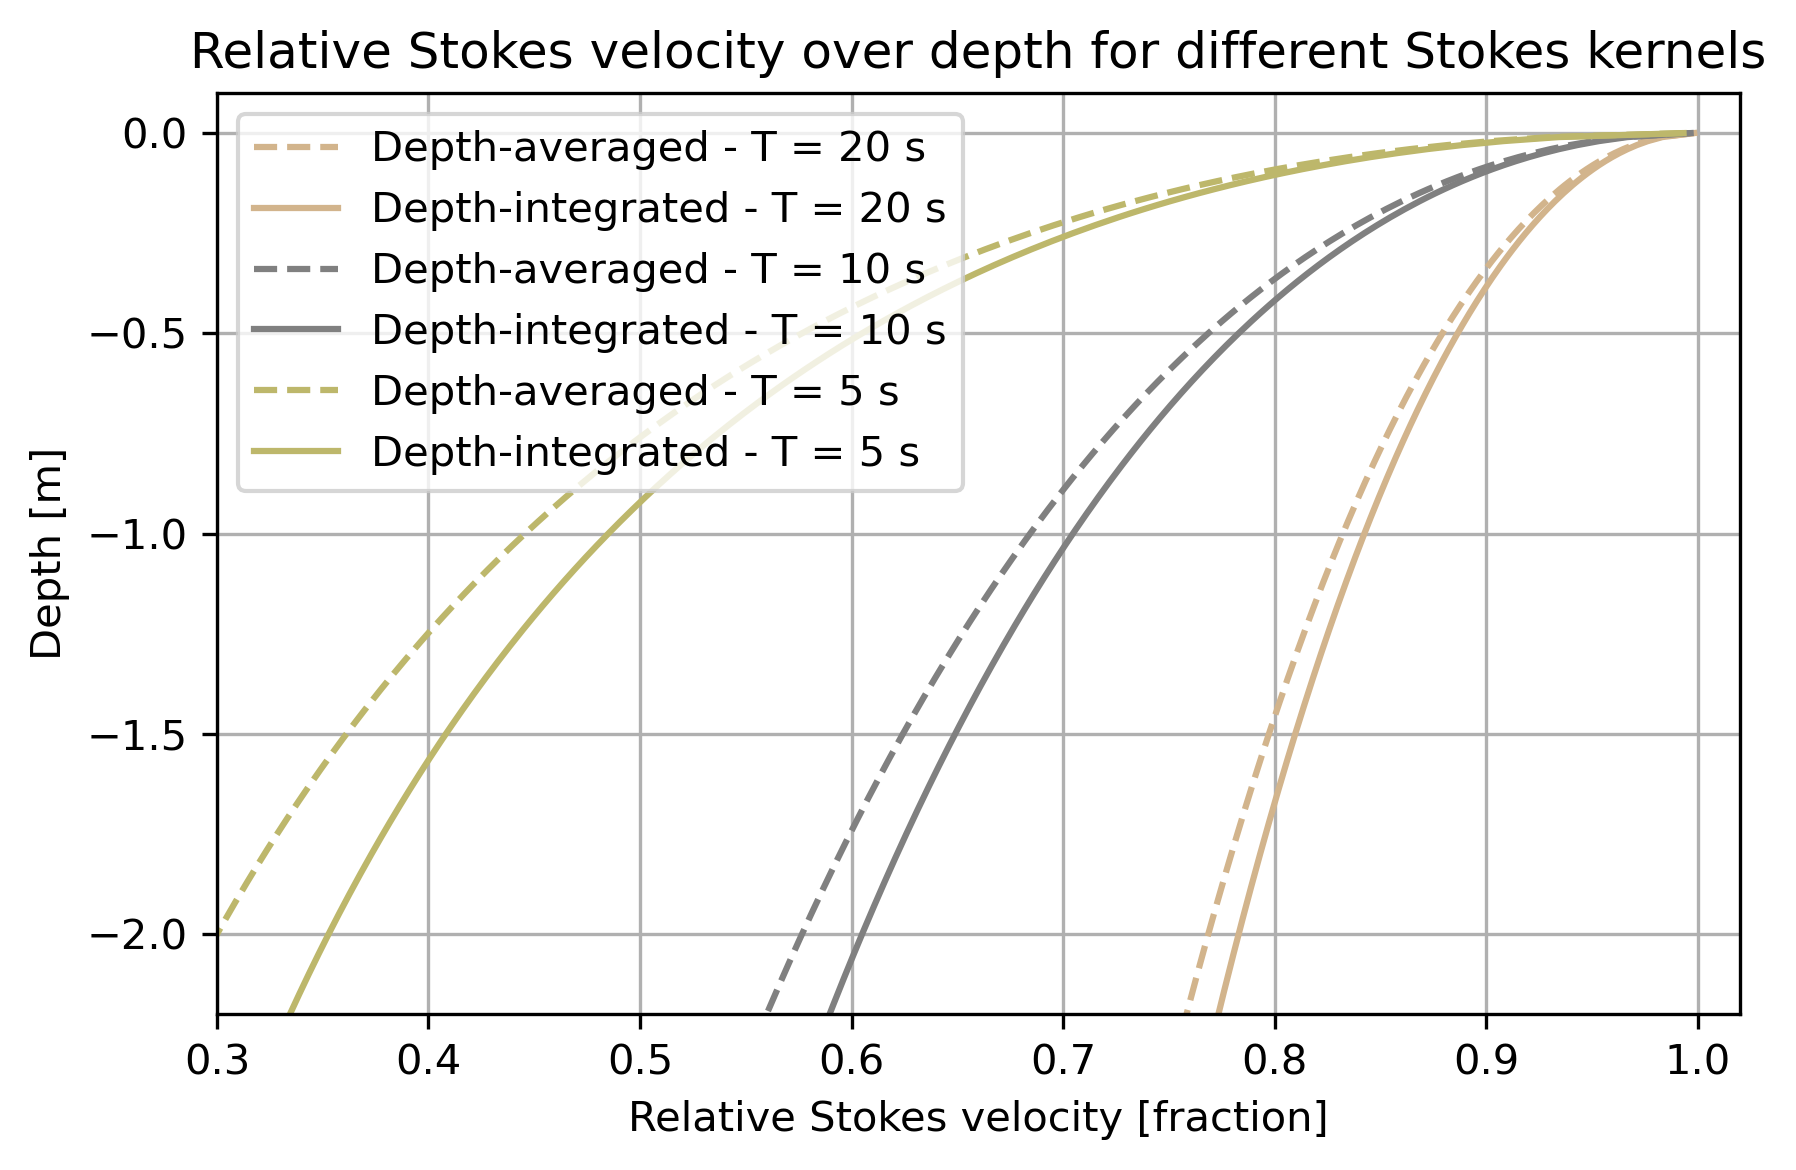

In [35]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 4), dpi = 300)
#Temperature
ax1.plot(decay3, -delta_z, "--", label='Depth-averaged - T = 20 s', color = 'tan')
ax1.plot(decay_stokes_vel3, - delta_z ,"-", label='Depth-integrated - T = 20 s', color = 'tan')
ax1.plot(decay, -delta_z, "--", label='Depth-averaged - T = 10 s', color = 'grey')
ax1.plot( decay_stokes_vel, -delta_z ,"-", label='Depth-integrated - T = 10 s', color = 'grey')
ax1.plot(decay2, -delta_z, "--", label='Depth-averaged - T = 5 s', color = 'darkkhaki')
ax1.plot( decay_stokes_vel2, - delta_z, "-" , label='Depth-integrated - T = 5 s', color = 'darkkhaki')
ax1.set_xlabel(r'Relative Stokes velocity [fraction]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Relative Stokes velocity over depth for different Stokes kernels')
ax1.grid()
ax1.set_xlim(0.3, 1.02)
ax1.set_ylim(-2.2,0.1)
ax1.legend(loc='upper left')
#ax1.vlines(1,0.3,1.1, color = 'peru')

plt.tight_layout()
plt.show()